Import des librairies et de la base de données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [2]:
df = pd.read_csv(r"C:\Users\utilisateur\Downloads\histo_gazpar_merged.csv")

In [30]:
print(df["date_parsed"])

0          2024-07-01T00:00:00.000Z
1          2024-11-07T00:00:00.000Z
2          2024-07-01T00:00:00.000Z
3          2024-12-18T00:00:00.000Z
4          2024-07-03T00:00:00.000Z
                     ...           
1358663    2024-09-03T00:00:00.000Z
1358664    2024-09-03T00:00:00.000Z
1358665    2024-09-03T00:00:00.000Z
1358666    2024-07-17T00:00:00.000Z
1358667    2025-05-29T00:00:00.000Z
Name: date_parsed, Length: 1358668, dtype: object


Préparation des variables : "trend", "hdd_workday", "hdd_weekend".

In [3]:
# Chargement et conversion des dates
df['date_parsed'] = pd.to_datetime(df['date_parsed'])
df = df.sort_values(['pce', 'date_parsed'])

# Création de la variable 'trend' (tendance temporelle)
df['trend'] = (df['date_parsed'] - df['date_parsed'].min()).dt.days

# Identification des variables de calendrier [cite: 42, 66]
df['is_weekend'] = df['date_parsed'].dt.dayofweek.isin([5, 6]).astype(int)

# Calcul des interactions HDD x Calendrier [cite: 66, 67]
df['hdd_workday'] = df['hdd'] * (1 - df['is_weekend'])
df['hdd_weekend'] = df['hdd'] * df['is_weekend']

Ajout de la colonne : "Is_Public_Holiday"

In [13]:
# 1. L'import et l'initialisation tels qu'écrits sur votre image
from vacances_scolaires_france import SchoolHolidayDates
d = SchoolHolidayDates()

# 2. L'application sur votre colonne de dates pour créer la variable (0 ou 1)
df['is_school_holiday'] = df['date_parsed'].apply(lambda x: 1 if d.is_holiday(x.date()) else 0)

print("Colonne des vacances ajoutée avec succès !")

ModuleNotFoundError: No module named 'vacances_scolaires_france'

Nettoyage des outliers (méthode IQR)

In [44]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# =====================================================================
# ETAPE 1 & 2 : Modéliser l'impact de la température
# =====================================================================
df_daily = df.groupby('date_parsed').agg(
    total_conso=('valeur_energie_conso', 'sum'),
    nb_pce=('pce', 'nunique'),
    temperature=('temperature', 'mean')
).reset_index()

df_daily['conso_uni'] = df_daily['total_conso'] / df_daily['nb_pce']

# Création du modèle météo global
model = smf.ols('conso_uni ~ temperature + I(temperature**2)', data=df_daily).fit()


# =====================================================================
# ETAPE 3 : Calculer le Résidu (L'anomalie de comportement)
# =====================================================================
df['conso_predite'] = model.predict(df)

# On crée une NOUVELLE colonne "conso_residu". 
# (La colonne 'valeur_energie_conso' reste intacte).
df['conso_residu'] = df['valeur_energie_conso'] - df['conso_predite']


# =====================================================================
# ETAPE 4 : Nettoyage des Outliers basé sur le RÉSIDU
# =====================================================================
def remove_outliers_iqr(group):
    # L'analyse statistique (IQR) se fait UNIQUEMENT sur la colonne 'conso_residu'
    Q1 = group['conso_residu'].quantile(0.25)
    Q3 = group['conso_residu'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # On filtre les lignes où le résidu est normal
    return group[(group['conso_residu'] >= lower_bound) & 
                 (group['conso_residu'] <= upper_bound)]

# Application du filtre par compteur (PCE)
df_clean = df.groupby('pce').apply(remove_outliers_iqr).reset_index(drop=True)


# =====================================================================
# ETAPE 5 : Finalisation
# =====================================================================
# On supprime nos colonnes de calcul qui ne servent plus
df_clean = df_clean.drop(columns=['conso_predite', 'conso_residu'])

# On ne garde que les compteurs (PCE) fiables présents sur plus d'un an
pce_counts = df_clean.groupby('pce')['year'].nunique()
consistent_pce = pce_counts[pce_counts >= 2].index

df_final = df_clean[df_clean['pce'].isin(consistent_pce)]

C:\Users\utilisateur\AppData\Local\Temp\ipykernel_23008\2839266106.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df.groupby('pce').apply(remove_outliers_iqr).reset_index(drop=True)


Application de LMM

Démarrage du modèle LMM...
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: valeur_energie_conso
No. Observations: 1229104 Method:             REML                
No. Groups:       5611    Scale:              112.7708            
Min. group size:  3       Log-Likelihood:     -4675226.6155       
Max. group size:  254     Converged:          Yes                 
Mean group size:  219.1                                           
------------------------------------------------------------------
                      Coef.  Std.Err.    z     P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept             13.372    0.078  171.673 0.000 13.220 13.525
hdd                    3.373    0.039   87.590 0.000  3.297  3.448
trend                 -0.047    0.000 -241.056 0.000 -0.047 -0.047
Is_Public_Holiday      0.098    0.055    1.791 0.073 -0.009  0.205
sin_month              6.454    0.029  221.610 0.0

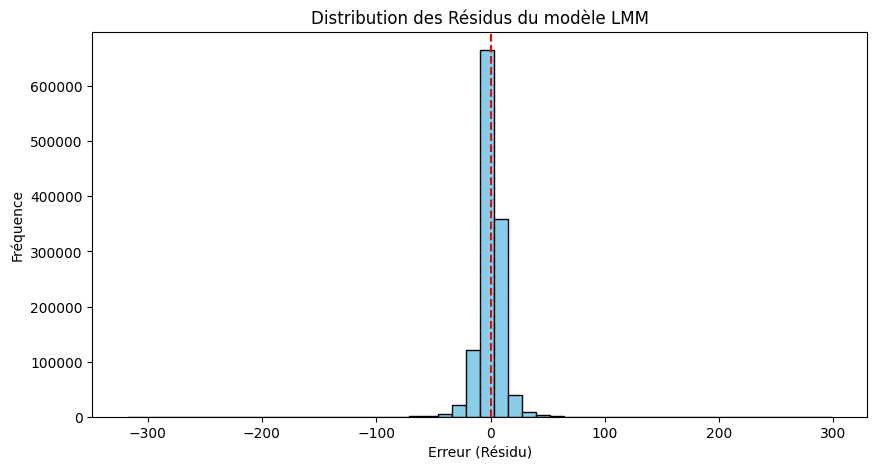

In [ ]:
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# On repart du dataframe
df_lmm = df_final.copy()

# Saisonnalité

# Saisonnalité Annuelle / Mensuelle (Période = 365.25 jours)
df_lmm['day_of_year'] = df_lmm['date_parsed'].dt.dayofyear
df_lmm['sin_month'] = np.sin(2 * np.pi * df_lmm['day_of_year'] / 365.25)
df_lmm['cos_month'] = np.cos(2 * np.pi * df_lmm['day_of_year'] / 365.25)

# Saisonnalité Hebdomadaire (Période = 7 jours)
df_lmm['day_of_week'] = df_lmm['date_parsed'].dt.dayofweek
df_lmm['sin_week'] = np.sin(2 * np.pi * df_lmm['day_of_week'] / 7)
df_lmm['cos_week'] = np.cos(2 * np.pi * df_lmm['day_of_week'] / 7)


# Selection du sous échantillon (ici tous les compteurs car ntile100 == 1)
data_for_model = df_lmm[df_lmm['ntile100'] == 1].copy()


# 3. Régression
formula = "valeur_energie_conso ~ hdd + trend + Is_Public_Holiday + sin_month + cos_month + sin_week + cos_week"

print("Démarrage du modèle LMM...")
        
# re_formula="~hdd" : Pente aléatoire pour le HDD brut
model_lmm = smf.mixedlm(formula, data_for_model, groups=data_for_model["pce"], re_formula="~hdd")
        
# method=["lbfgs"] est plus robuste pour converger
result_lmm = model_lmm.fit(method=["lbfgs"], maxiter=200)

print(result_lmm.summary())


# 4. Analyse des résidus
# On extrait les erreurs du modèle (Ce que le modèle n'a pas su prédire)
data_for_model['residus'] = result_lmm.resid

print("\n--- Analyse des Résidus ---")
print(data_for_model['residus'].describe())

# Visualisation rapide des résidus (Optionnel mais recommandé)
plt.figure(figsize=(10, 5))
plt.hist(data_for_model['residus'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution des Résidus du modèle LMM")
plt.xlabel("Erreur (Résidu)")
plt.ylabel("Fréquence")
plt.axvline(0, color='red', linestyle='dashed', linewidth=1.5)
plt.show()

Résultats du LMM

In [56]:
# Résultats du modèle
print(result_lmm.summary())
        
# Effets aléatoires:
print("Exemple d'Effets Aléatoire:")
print(pd.DataFrame(result_lmm.random_effects).T.head(5))

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: valeur_energie_conso
No. Observations: 1229104 Method:             REML                
No. Groups:       5611    Scale:              112.7708            
Min. group size:  3       Log-Likelihood:     -4675226.6155       
Max. group size:  254     Converged:          Yes                 
Mean group size:  219.1                                           
------------------------------------------------------------------
                      Coef.  Std.Err.    z     P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept             13.372    0.078  171.673 0.000 13.220 13.525
hdd                    3.373    0.039   87.590 0.000  3.297  3.448
trend                 -0.047    0.000 -241.056 0.000 -0.047 -0.047
Is_Public_Holiday      0.098    0.055    1.791 0.073 -0.009  0.205
sin_month              6.454    0.029  221.610 0.000  6.397  6.512
cos_month 

Stockage des résultats dans "df_results"

In [59]:
# Extraction des Effets Fixes (Population globale)
beta_hdd_fixed = result_lmm.params['hdd']

# Extraction des Effets Aléatoires (Spécifiques par client): le dico result_lmm.random_effects contient les écarts pour chaque PCE
re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')
re_df = re_df.rename(columns={'hdd': 'hdd_random_slope', 'Group': 'intercept_random'})
re_df.index.name = 'pce'

# Fusion avec les données d'origine utilisées dans le modèle
df_results = data_for_model.copy()
df_results = df_results.merge(re_df, on='pce', how='left')

# Calcul de la pente totale : Pente Client = Pente Moyenne (Fixed) + Écart Client (Random)
df_results['total_hdd_slope'] = beta_hdd_fixed + df_results['hdd_random_slope']

# Calcul de la Consommation Normalisée (On retire l'effet météo spécifique à ce client pour ne garder que le comportement : Conso_Norm = Conso_Reelle - (Sensibilité_Client * Météo)
df_results['conso_norm'] = df_results['valeur_energie_conso'] - (df_results['total_hdd_slope'] * df_results['hdd'])

Evolution d'une années sur l'autre (pb car ici juste 1 an)

In [60]:
# Agrégation Mensuelle : On fait la moyenne des consos normalisées par mois
summary_lmm = df_results.groupby(['year', 'month'])['conso_norm'].mean().reset_index()

# Pivot pour comparer les années (2025 vs 2024)
pivot_lmm = summary_lmm.pivot(index='month', columns='year', values='conso_norm')

# Calcul de l'évolution
if 2024 in pivot_lmm.columns and 2025 in pivot_lmm.columns:
    pivot_lmm['Evolution_2025_vs_2024 (%)'] = ((pivot_lmm[2025] - pivot_lmm[2024]) / pivot_lmm[2024]) * 100
    
    print("\n RÉSULTATS FINAUX ")
    print("Évolution de la consommation corrigée du climat (Demand Destruction) :")
    print(pivot_lmm[['Evolution_2025_vs_2024 (%)']].round(2))
    
    avg_drop = pivot_lmm['Evolution_2025_vs_2024 (%)'].mean()
    print(f"\n>> Moyenne globale de la baisse sur la période : {avg_drop:.2f}%")
else:
    print("Pas assez de données communes pour comparer les années.")


 RÉSULTATS FINAUX 
Évolution de la consommation corrigée du climat (Demand Destruction) :
year   Evolution_2025_vs_2024 (%)
month                            
1                             NaN
2                             NaN
3                             NaN
4                             NaN
5                             NaN
7                             NaN
8                             NaN
9                             NaN
10                            NaN
11                            NaN
12                            NaN

>> Moyenne globale de la baisse sur la période : nan%


Réprésentation graphique des résultats
- 1 : Scatter plot pour individus
- 2 : Evolution de la conso sans l'effet météo

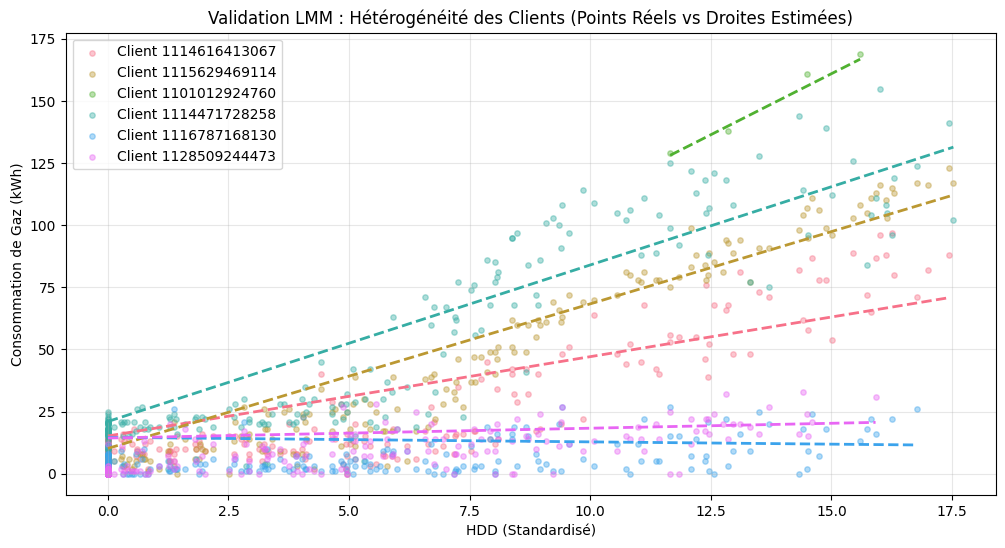

In [63]:
# Objectif : Montrer que chaque client réagit différemment au froid (Pentes aléatoires)

# Sélection de 6 clients aléatoires
sample_pces = np.random.choice(df_results['pce'].unique(), 6, replace=False)
subset_plot = df_results[df_results['pce'].isin(sample_pces)].copy()

plt.figure(figsize=(12, 6))

# Palette de couleurs pour distinguer les clients
colors = sns.color_palette("husl", len(sample_pces))

for i, pce in enumerate(sample_pces):
    pce_data = subset_plot[subset_plot['pce'] == pce]
    color = colors[i]
    
    # Nuage de points
    plt.scatter(pce_data['hdd'], pce_data['valeur_energie_conso'], 
                alpha=0.4, s=15, color=color, label=f"Client {pce}")
    
    # Droite du Modèle LMM (Pente spécifique à ce client)
    # y = (Intercept_Fixe + Intercept_Random) + (Pente_Fixe + Pente_Random) * X
    intercept_fixed = result_lmm.params['Intercept']
    intercept_total = intercept_fixed + pce_data['intercept_random'].iloc[0]
    slope_total = pce_data['total_hdd_slope'].iloc[0]
    
    # Création de la ligne de régression
    x_vals = np.array([pce_data['hdd'].min(), pce_data['hdd'].max()])
    y_vals = intercept_total + slope_total * x_vals
    
    plt.plot(x_vals, y_vals, color=color, linewidth=2, linestyle='--')

plt.title("Validation LMM : Hétérogénéité des Clients (Points Réels vs Droites Estimées)")
plt.xlabel("HDD (Standardisé)")
plt.ylabel("Consommation de Gaz (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

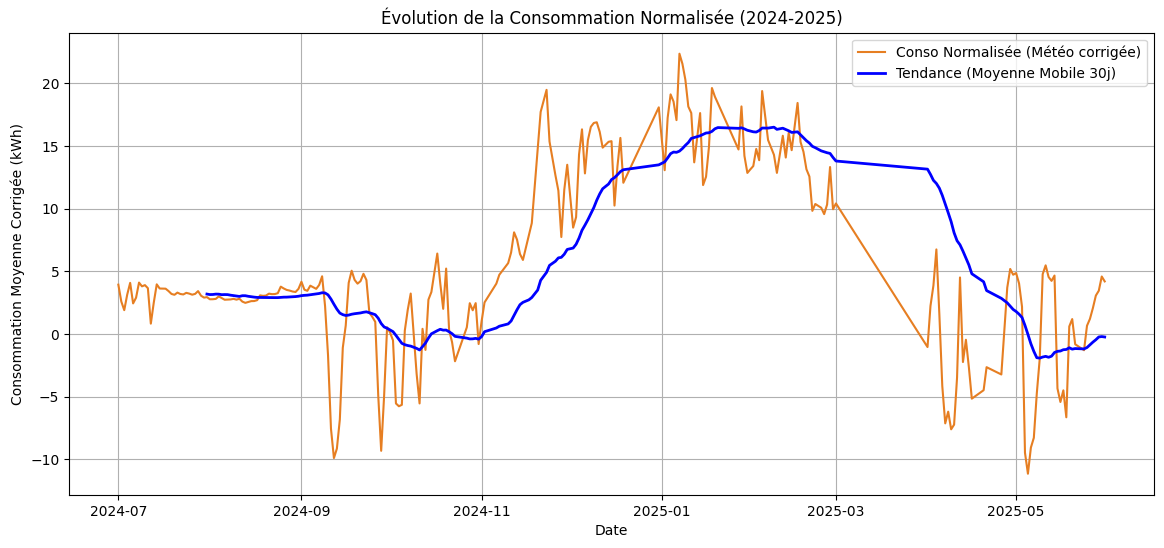

In [65]:
# Objectif : Voir la courbe de consommation "nettoyée" de la météo
plt.figure(figsize=(14, 6))

# On agrège par jour pour alléger le graphique
daily_trend = df_results.groupby('date_parsed')['conso_norm'].mean()

# Tracé de la courbe
plt.plot(daily_trend.index, daily_trend.values, color='#e67e22', linewidth=1.5, label='Conso Normalisée (Météo corrigée)')

# Ajout d'une moyenne mobile pour voir la tendance de fond (Trend)
plt.plot(daily_trend.rolling(window=30).mean().index, 
         daily_trend.rolling(window=30).mean().values, 
         color='blue', linewidth=2, linestyle='-', label='Tendance (Moyenne Mobile 30j)')

plt.title("Évolution de la Consommation Normalisée (2024-2025)")
plt.ylabel("Consommation Moyenne Corrigée (kWh)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()